# INTRODUCTION

In today's digital era, romantic relationships increasingly begin and evolve through online platforms. Dating apps such as Tinder, Bumble, and Hinge, along with social media platforms like Instagram and WhatsApp, have transformed how people connect, communicate, and form emotional bonds.

Unlike traditional relationships where interactions happen face-to-face, digital relationships leave behind measurable behavioral data:
- Response time to messages
- Emoji usage patterns
- Online activity frequency
- Conversation length and depth
- Engagement metrics (likes, reactions, shares)

These digital footprints create an opportunity to apply machine learning for understanding relationship dynamics. However, prediction alone is insufficient. To truly understand human connections, we must also answer *why* certain outcomes occur.

This assignment implements a **hybrid machine learning approach** that combines:
1. **Classification** – Predicting relationship match outcomes (e.g., Will the match lead to a date? Will ghosting occur?)
2. **Interpretability** – Explaining which digital behaviors most influence predictions

By using both traditional and advanced models, and comparing Random Forest vs XGBoost, we aim to build a system that is both accurate and transparent in **predicting Hybrid Match Outcome and Feature Importance**, which is who is compatible and why exactly are they compatible!

# Problem Setup

### Domain Context
In modern dating apps (Tinder, Bumble, Hinge, etc.), user behavior generates rich digital footprints. From swipe patterns to response times, from profile completeness to personality indicators — these data points may reveal insights about relationship success, match compatibility, and user engagement.

### The Problem
Dating app users often wonder: *What makes a match successful?* Is it how often you swipe right? Your education level? Your personality type? Your daily app usage?

This project aims to predict **match outcome** (Will this user find a successful match? Will they get ghosted?) based on their behavioral and demographic data.

### ML Problem Type
- **Supervised Binary Classification**
- **Target Variable**: Match Outcome / Dating Success (1 = Successful, 0 = Unsuccessful/Ghosted)

### Features in Your Dataset

Based on the data you shared, here are the actual features:

| Feature | Description | Type |
|---------|-------------|------|
| **Demographic Features** |||
| gender | User’s gender identity (Female, Non-binary, Other) | Categorical |
| sexual_orientation | User’s sexual orientation (Straight, Lesbian, Gay, Other) | Categorical |
| location_type | Type of location (Urban, Small Town, Remote Area, Other) | Categorical |
| income_bracket | Income level (High, Very High, Other) | Categorical |
| education_level | Highest education attained (Bachelor’s, MBA, Other) | Categorical |
| **Behavioral Features** |||
| app_usage_time_min | Daily app usage time in minutes | Numerical |
| app_usage_time_label | Categorical label for usage time (e.g., Moderate, Heavy) | Categorical |
| swipe_right_ratio | Ratio of right swipes to total swipes (0.00 to 1.00) | Numerical |
| swipe_right_label | Categorical label for swipe ratio | Categorical |
| **Personality Feature** |||
| personality_type | User personality type (Optimistic, Balanced, Other) | Categorical |
| **Text Feature** |||
| interest_tags | Comma-separated list of user interests (e.g., Fitness, Politics, Traveling) | Text |

### Why These Features Matter (Hypotheses)

| Feature | Hypothesis |
|---------|------------|
| swipe_right_ratio | Too high (swiping everyone) or too low (too picky) may predict poor outcomes |
| app_usage_time | Excessive usage might indicate addiction vs. healthy engagement |
| education_level | May correlate with communication quality or compatibility |
| personality_type | Optimistic users might have better dating experiences |
| interest_tags | Shared interests could predict match success |
| location_type | Urban users may have more options vs. remote areas |

### Success Metrics
- **Primary Metrics**: Accuracy, Precision, Recall, F1-Score
- **Interpretability**: Feature importance ranking to identify strongest predictors
- **Model Comparison**: Basic vs Advanced models performance

### Models to Implement

| Type | Models |
|------|--------|
| Basic | Logistic Regression, Decision Tree |
| Advanced | Random Forest, XGBoost (with hyperparameter tuning) |

### Expected Outcomes

1. **Prediction**: Which user behaviors best predict dating success?
2. **Interpretation**: Which features matter most? (e.g., Is swipe ratio more important than education?)
3. **Comparison**: Do advanced models (XGBoost) significantly outperform basic ones?

In [ ]:
# Hybrid Match Outcome + Feature Importance

# DATA MANIPULATION
import pandas as pd
import numpy as np

# DATA VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

# DATA PREPROCESSING
import sklearn # Explicitly import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer

# BASIC MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# ADVANCED MODELS
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb # Explicitly import xgboost as xgb
from xgboost import XGBClassifier

# EVALUATION METRICS
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    auc
)

# FEATURE IMPORTANCE & INTERPRETABILITY
from sklearn.inspection import permutation_importance
import shap

# WARNINGS
import warnings
warnings.filterwarnings('ignore')

# DISPLAY SETTINGS
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# VERSION CHECK
print("=" * 40)
print("LIBRARIES IMPORTED SUCCESSFULLY!")
print("=" * 40)
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print(f"Seaborn version: {sns.__version__}")
print("=" * 40)


LIBRARIES IMPORTED SUCCESSFULLY!
Pandas version: 2.2.2
NumPy version: 2.0.2
Scikit-learn version: 1.6.1
XGBoost version: 3.2.0
Seaborn version: 0.13.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Try listing the contents of your Google Drive to verify the file path
# import os
# print(os.listdir('/content/drive/MyDrive'))

df = pd.read_csv('/content/drive/MyDrive/dating_app_behavior_dataset.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


# 1. Data Preprocessing

## Drop Unused Columns
This code app_usage_time_label and swipe_right_label because they are redundant categorical versions of existing numerical data.

In [ ]:
# Drop redundant columns that are just labels of numerical features
columns_to_drop = ['app_usage_time_label', 'swipe_right_label']
df_cleaned = df.drop(columns=columns_to_drop)

# Verify the cleansing results
print(f"Data shape after cleaning: {df_cleaned.shape}")
print(f"Target classes preserved: {df_cleaned['match_outcome'].nunique()}")

# Display cleaned dataframe head
df_cleaned.head()

Data shape after cleaning: (50000, 17)
Target classes preserved: 10


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,0.60,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,0.56,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,0.41,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,0.32,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,0.32,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


## Null Values

This displays the count of null values for every column to ensure data completeness

In [ ]:
null_summary = df_cleaned.isnull().sum()
print("Missing Values Summary:\n", null_summary)

Missing Values Summary:
 gender                0
sexual_orientation    0
location_type         0
income_bracket        0
education_level       0
interest_tags         0
app_usage_time_min    0
swipe_right_ratio     0
likes_received        0
mutual_matches        0
profile_pics_count    0
bio_length            0
message_sent_count    0
emoji_usage_rate      0
last_active_hour      0
swipe_time_of_day     0
match_outcome         0
dtype: int64


## Duplicate Values

To ensure the robustness of the predictive models, a duplicate check is performed to identify redundant observations within the dataset.

In [ ]:
# Identifying the number of duplicate rows before removal
duplicate_count = df_cleaned.duplicated().sum()
print(f"\nTotal duplicate rows found: {duplicate_count}")

# Physical removal of duplicates to ensure each observation is unique
df_cleaned = df_cleaned.drop_duplicates().reset_index(drop=True)
print(f"Data shape after removing duplicates: {df_cleaned.shape}")


Total duplicate rows found: 0
Data shape after removing duplicates: (50000, 17)


## Feature Engineering

The interest_count feature is created by counting the comma-separated values in `interest_tags`, representing the breadth of a user's social profile. A `profile_richness` indicator combines bio_length and profile_pics_count to measure the effort a user puts into their profile. Finally, an `engagement_efficiency` ratio is calculated from mutual_matches and likes_received to identify high-performing profiles regardless of their total volume of interactions.

In [ ]:
# 1. Extract Interest Count
# Counts how many interests a user has listed
df_cleaned['interest_count'] = df_cleaned['interest_tags'].apply(lambda x: len(str(x).split(',')))

# 2. Create Profile Richness Score
# Combines bio length and picture count to estimate profile effort
df_cleaned['profile_richness'] = df_cleaned['bio_length'] + (df_cleaned['profile_pics_count'] * 50)

# 3. Calculate Engagement Efficiency
# Measures how many matches are generated per like received
df_cleaned['engagement_efficiency'] = np.where(
    df_cleaned['likes_received'] > 0,df_cleaned['mutual_matches'] / df_cleaned['likes_received'],
    0
)

# 4. Message-to-Emoji Ratio
df_cleaned['emoji_intensity'] = df_cleaned['emoji_usage_rate'] * df_cleaned['message_sent_count']

print("New features created:")
print(df_cleaned[['interest_count', 'profile_richness', 'engagement_efficiency', 'emoji_intensity']].head())
print(f"\nTotal columns now: {df_cleaned.shape[1]}")

New features created:
   interest_count  profile_richness  engagement_efficiency  emoji_intensity
0               3               244               0.132948            27.00
1               3               451               0.065421            14.70
2               3               409               0.296703            13.53
3               3               285               0.040816             0.35
4               3               393               0.117021             3.74

Total columns now: 21


## Encoding Categorial Variables

To facilitate mathematical computation, categorical variables are transformed into numerical formats. The target variable, match_outcome, is processed via Label Encoding to map the ten distinct classes into discrete integers. Features with multiple tags are expanded into binary indicators, while other nominal features are transformed to avoid imposing an artificial ordinal relationship between categories.

In [ ]:
# 1. Encode Target Variable (match_outcome)
# Convert 10 categorical outcomes into numerical labels 0-9
label_encoder = LabelEncoder()
df_cleaned['match_outcome'] = label_encoder.fit_transform(df_cleaned['match_outcome'])

# 2. Process Interest Tags
interests_expanded = df_cleaned['interest_tags'].str.get_dummies(sep=', ')
df_encoded = pd.concat([df_cleaned.drop('interest_tags', axis=1), interests_expanded], axis=1)

# 3. One-Hot Encoding for Categorical Features
# Convert remaining text categories into binary columns
categorical_cols = ['gender', 'sexual_orientation', 'location_type', 'income_bracket',
                    'education_level', 'swipe_time_of_day']

df_final = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

print(f"Final Data Shape: {df_final.shape}")
df_final.head()

Final Data Shape: (50000, 99)


,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,match_outcome,interest_count,profile_richness,engagement_efficiency,emoji_intensity,Anime,Art,Astrology,Binge-Watching,Board Games,Cars,Clubbing,Coding,Cooking,Crafting,DIY,Dancing,Fashion,Fitness,Foodie,Gaming,Gardening,Hiking,History,Investing,K-pop,Languages,MMA,Makeup,Meditation,Memes,Motorcycling,Movies,Music,Painting,Parenting,Pets,Photography,Podcasts,Poetry,Politics,Reading,Running,Skating,Sneaker Culture,Social Activism,Spirituality,Stand-up Comedy,Startups,Tattoos,Tech,Traveling,Writing,Yoga,gender_Genderfluid,gender_Male,gender_Non-binary,gender_Prefer Not to Say,gender_Transgender,sexual_orientation_Bisexual,sexual_orientation_Demisexual,sexual_orientation_Gay,sexual_orientation_Lesbian,sexual_orientation_Pansexual,sexual_orientation_Queer,sexual_orientation_Straight,location_type_Remote Area,location_type_Rural,location_type_Small Town,location_type_Suburban,location_type_Urban,income_bracket_Low,income_bracket_Lower-Middle,income_bracket_Middle,income_bracket_Upper-Middle,income_bracket_Very High,income_bracket_Very Low,education_level_Bachelor’s,education_level_Diploma,education_level_High School,education_level_MBA,education_level_Master’s,education_level_No Formal Education,education_level_PhD,education_level_Postdoc,swipe_time_of_day_Afternoon,swipe_time_of_day_Early Morning,swipe_time_of_day_Evening,swipe_time_of_day_Late Night,swipe_time_of_day_Morning
0,52,0.60,173,23,4,44,75,0.36,13,6,3,244,0.132948,27.00,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False
1,279,0.56,107,7,3,301,35,0.42,0,2,3,451,0.065421,14.70,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
2,49,0.41,91,27,2,309,33,0.41,1,3,3,409,0.296703,13.53,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,185,0.32,147,6,5,35,5,0.07,21,7,3,285,0.040816,0.35,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True
4,83,0.32,94,11,1,343,34,0.11,22,8,3,393,0.117021,3.74,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
print('Original match_outcome classes:', label_encoder.classes_)

Original match_outcome classes: ['Blocked' 'Catfished' 'Chat Ignored' 'Date Happened' 'Ghosted'
 'Instant Match' 'Mutual Match' 'No Action' 'One-sided Like'
 'Relationship Formed']


## Feature Scaling

Since different features have vast differences in magnitude—for instance, likes_received ranges up to 200 while swipe_right_ratio is between 0 and 1.Standardization is necessary to ensure models treat all features fairly.

In [ ]:
# 1. Identify all numerical columns
# exclude the target 'match_outcome' and the binary (0/1) dummy columns
num_features = [
    'app_usage_time_min', 'swipe_right_ratio', 'likes_received', 'mutual_matches',
    'profile_pics_count', 'bio_length', 'message_sent_count', 'emoji_usage_rate',
    'last_active_hour', 'interest_count', 'profile_richness',
    'engagement_efficiency', 'emoji_intensity'
]

# 2. Initialize and apply the StandardScaler
scaler = StandardScaler()

# Create a copy of the final dataframe to avoid setting with copy warnings
df_scaled = df_final.copy()
df_scaled[num_features] = scaler.fit_transform(df_scaled[num_features])

# 3. display
print("Standardization Complete.")
print(f"Mean of likes_received after scaling: {df_scaled['likes_received'].mean():.2f}")
print(f"Standard deviation of likes_received: {df_scaled['likes_received'].std():.2f}")

df_scaled.head()

Standardization Complete.
Mean of likes_received after scaling: 0.00
Standard deviation of likes_received: 1.00


,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,match_outcome,interest_count,profile_richness,engagement_efficiency,emoji_intensity,Anime,Art,Astrology,Binge-Watching,Board Games,Cars,Clubbing,Coding,Cooking,Crafting,DIY,Dancing,Fashion,Fitness,Foodie,Gaming,Gardening,Hiking,History,Investing,K-pop,Languages,MMA,Makeup,Meditation,Memes,Motorcycling,Movies,Music,Painting,Parenting,Pets,Photography,Podcasts,Poetry,Politics,Reading,Running,Skating,Sneaker Culture,Social Activism,Spirituality,Stand-up Comedy,Startups,Tattoos,Tech,Traveling,Writing,Yoga,gender_Genderfluid,gender_Male,gender_Non-binary,gender_Prefer Not to Say,gender_Transgender,sexual_orientation_Bisexual,sexual_orientation_Demisexual,sexual_orientation_Gay,sexual_orientation_Lesbian,sexual_orientation_Pansexual,sexual_orientation_Queer,sexual_orientation_Straight,location_type_Remote Area,location_type_Rural,location_type_Small Town,location_type_Suburban,location_type_Urban,income_bracket_Low,income_bracket_Lower-Middle,income_bracket_Middle,income_bracket_Upper-Middle,income_bracket_Very High,income_bracket_Very Low,education_level_Bachelor’s,education_level_Diploma,education_level_High School,education_level_MBA,education_level_Master’s,education_level_No Formal Education,education_level_PhD,education_level_Postdoc,swipe_time_of_day_Afternoon,swipe_time_of_day_Early Morning,swipe_time_of_day_Evening,swipe_time_of_day_Late Night,swipe_time_of_day_Morning
0,-1.125564,0.503097,1.266875,1.002657,0.506961,-1.423861,0.854646,0.461100,0.213600,6,0.0,-0.881328,-0.374165,1.012413,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False
1,1.483942,0.300530,0.128870,-0.754518,0.006150,0.351007,-0.516734,0.836006,-1.664903,2,0.0,0.291431,-0.678362,0.028355,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
2,-1.160051,-0.459093,-0.147010,1.441951,-0.494661,0.406255,-0.585303,0.773521,-1.520402,3,0.0,0.053480,0.363517,-0.065250,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,0.403354,-0.914868,0.818570,-0.864341,1.007773,-1.486016,-1.545268,-1.350944,1.369602,7,0.0,-0.649042,-0.789199,-1.119712,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True
4,-0.769200,-0.914868,-0.095283,-0.315224,-0.995473,0.641063,-0.551018,-1.101006,1.514102,8,0.0,-0.037168,-0.445912,-0.848496,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Define mapping for binary target variable
successful_outcomes = [
    'Date Happened',
    'Mutual Match',
    'Instant Match',
    'Relationship Formed'
]

# Map original labels to 1 (Successful) or 0 (Unsuccessful)
df_scaled['binary_match_outcome'] = df_cleaned['match_outcome'].apply(
    lambda x: 1 if label_encoder.inverse_transform([x])[0] in successful_outcomes else 0
)

# Drop the original multi-class target column from df_scaled
df_scaled = df_scaled.drop(columns=['match_outcome'], errors='ignore')

print("Binary target variable 'binary_match_outcome' created.")
print(df_scaled['binary_match_outcome'].value_counts(normalize=True))


Binary target variable 'binary_match_outcome' created.
binary_match_outcome
0    0.603
1    0.397
Name: proportion, dtype: float64


A distribution analysis of the target variable, match_outcome. This verification is crucial to ensure that the dataset is balanced, preventing the model from developing a bias toward majority classes.

Target Class Distribution (%):
binary_match_outcome
0    60.3
1    39.7
Name: proportion, dtype: float64


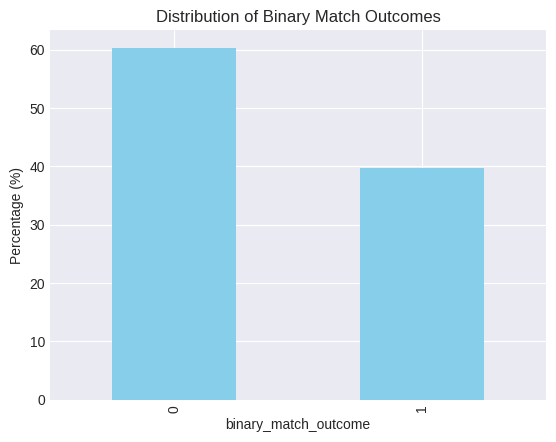

In [ ]:
# Check the percentage of each outcome
target_distribution = df_scaled['binary_match_outcome'].value_counts(normalize=True) * 100

print("Target Class Distribution (%):")
print(target_distribution)

# Visualization for the report
import matplotlib.pyplot as plt
target_distribution.plot(kind='bar', color='skyblue')
plt.title('Distribution of Binary Match Outcomes')
plt.ylabel('Percentage (%)')
plt.show()

# 2. Exploratory Data Analysis (EDA)

## Data Overview

This section explores the dataset to understand its structure, distribution, and relationships between variables before building machine learning models.


In [ ]:
print(df.shape)

(50000, 19)


In [ ]:
df.head()

,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                50000 non-null  object 
 1   sexual_orientation    50000 non-null  object 
 2   location_type         50000 non-null  object 
 3   income_bracket        50000 non-null  object 
 4   education_level       50000 non-null  object 
 5   interest_tags         50000 non-null  object 
 6   app_usage_time_min    50000 non-null  int64  
 7   app_usage_time_label  50000 non-null  object 
 8   swipe_right_ratio     50000 non-null  float64
 9   swipe_right_label     50000 non-null  object 
 10  likes_received        50000 non-null  int64  
 11  mutual_matches        50000 non-null  int64  
 12  profile_pics_count    50000 non-null  int64  
 13  bio_length            50000 non-null  int64  
 14  message_sent_count    50000 non-null  int64  
 15  emoji_usage_rate   

In [ ]:
df.describe()

,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.000000
mean,149.912400,0.500655,99.526040,13.870280,2.98772,250.174400,50.07194,0.286205,11.521800
std,86.990521,0.197468,57.996799,9.105615,1.99678,144.800996,29.16800,0.160042,6.920474
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000
25%,74.000000,0.370000,49.000000,6.000000,1.00000,125.000000,25.00000,0.160000,5.000000
50%,150.000000,0.500000,100.000000,13.000000,3.00000,250.000000,50.00000,0.270000,12.000000
75%,225.000000,0.640000,150.000000,22.000000,5.00000,376.000000,75.00000,0.390000,18.000000
max,300.000000,1.000000,200.000000,30.000000,6.00000,500.000000,100.00000,0.940000,23.000000


## Import Visualization Libraries

We import visualization libraries to help us analyze data patterns visually.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Feature Distributions

We visualize the distribution of each numerical feature to understand skewness, spread, and potential outliers.

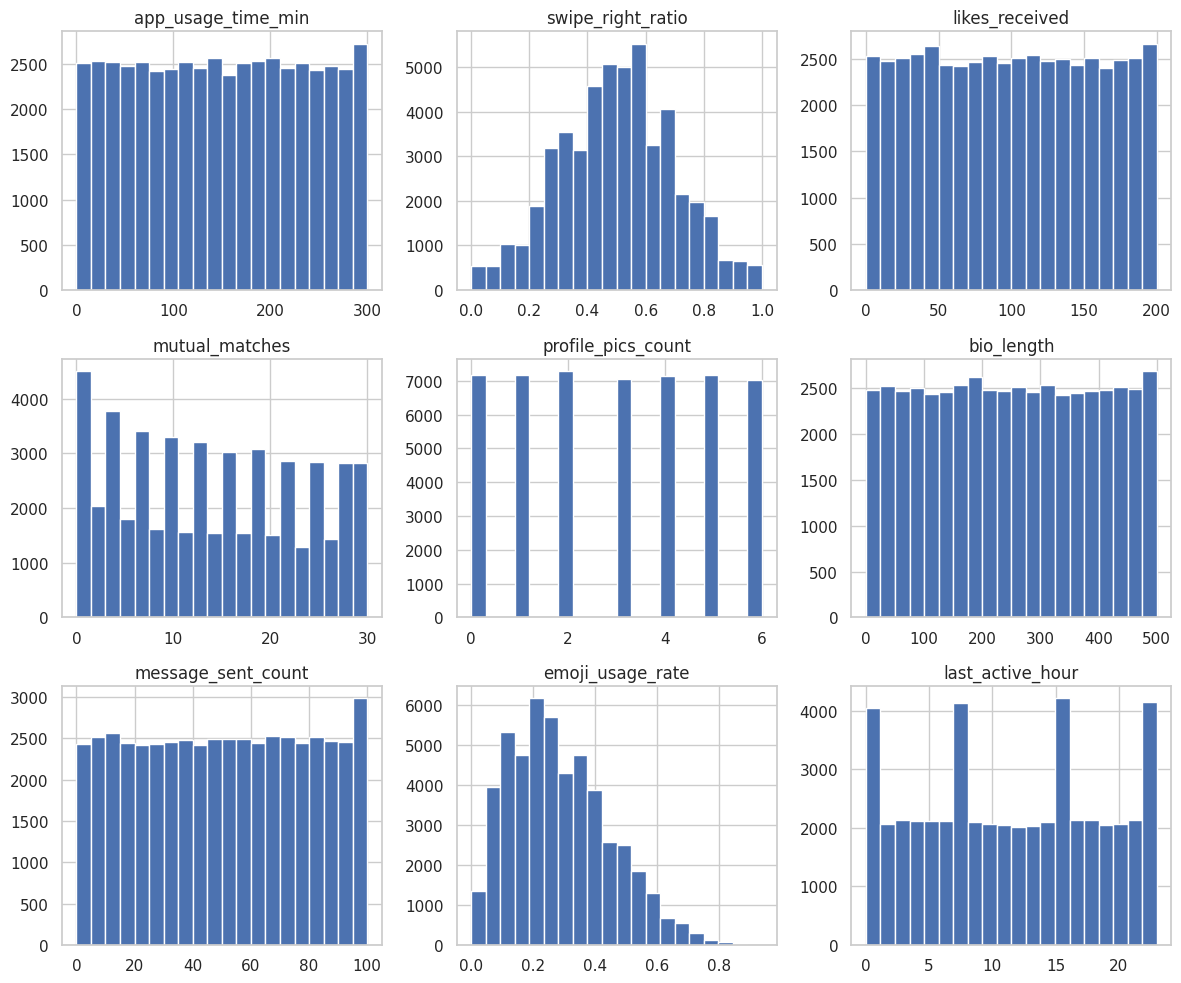

In [ ]:
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()


Several features exhibit skewed distributions, which may impact models that assume normality such as Logistic Regression.
Feature scaling or transformation may be required to improve model performance.

## Correlation Matrix

## Correlation Analysis

We analyze correlations between numerical features to identify relationships and possible feature redundancy.

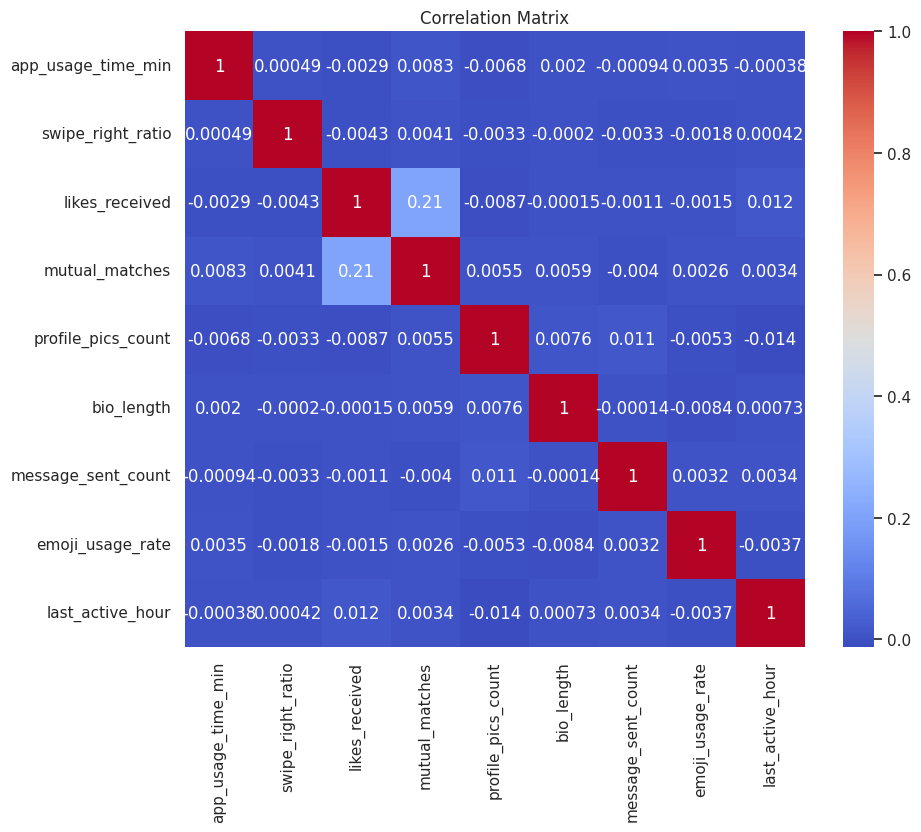

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


Some features show strong correlations with each other, indicating potential multicollinearity. Highly correlated features may not provide additional information and could affect linear models. However, tree-based models such as Decision Tree and Random Forest are less sensitive to this issue.

## Target Distribution

We examine the distribution of the target variable to check whether the dataset is balanced or imbalanced.

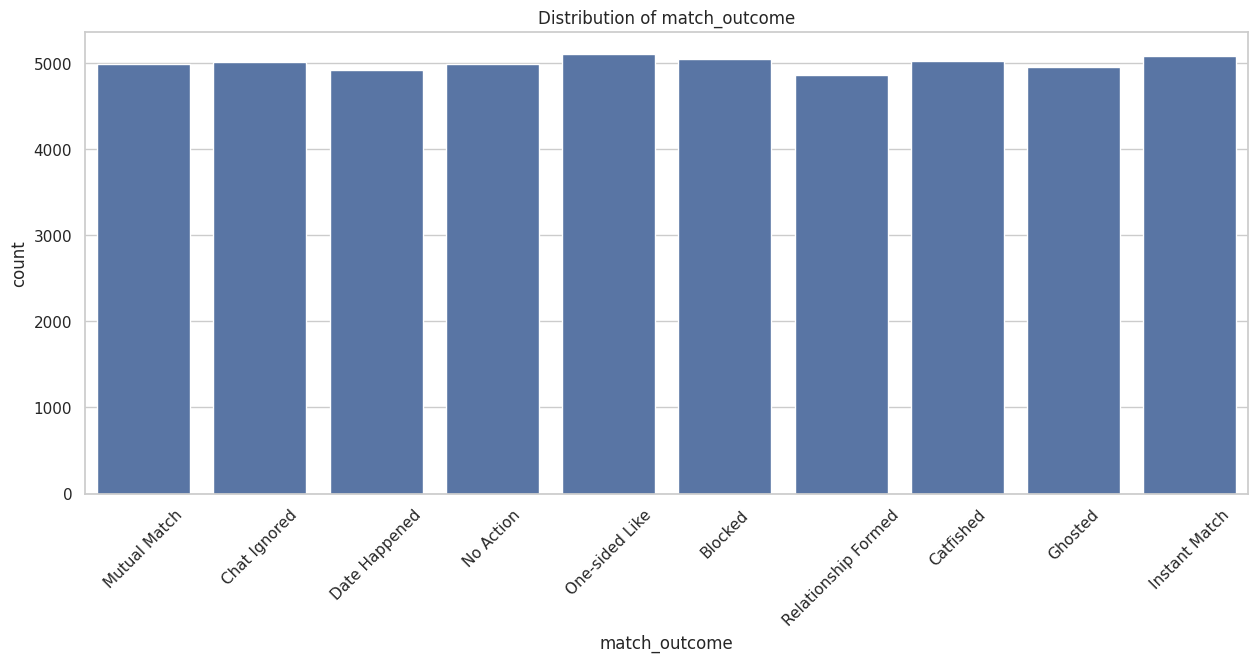

In [ ]:
TARGET='match_outcome'
plt.figure(figsize=(15, 6))
sns.countplot(x=TARGET, data=df)
plt.title(f'Distribution of {TARGET}')
plt.xticks(rotation=45)
plt.show()


The target variable distribution suggests that the dataset may be imbalanced. This could bias the model toward the majority class, and techniques such as resampling or class weighting may be necessary.ced or imbalanced, which is important for model selection and evaluation.

## Outlier Detection

Boxplots are used to detect outliers in numerical features.

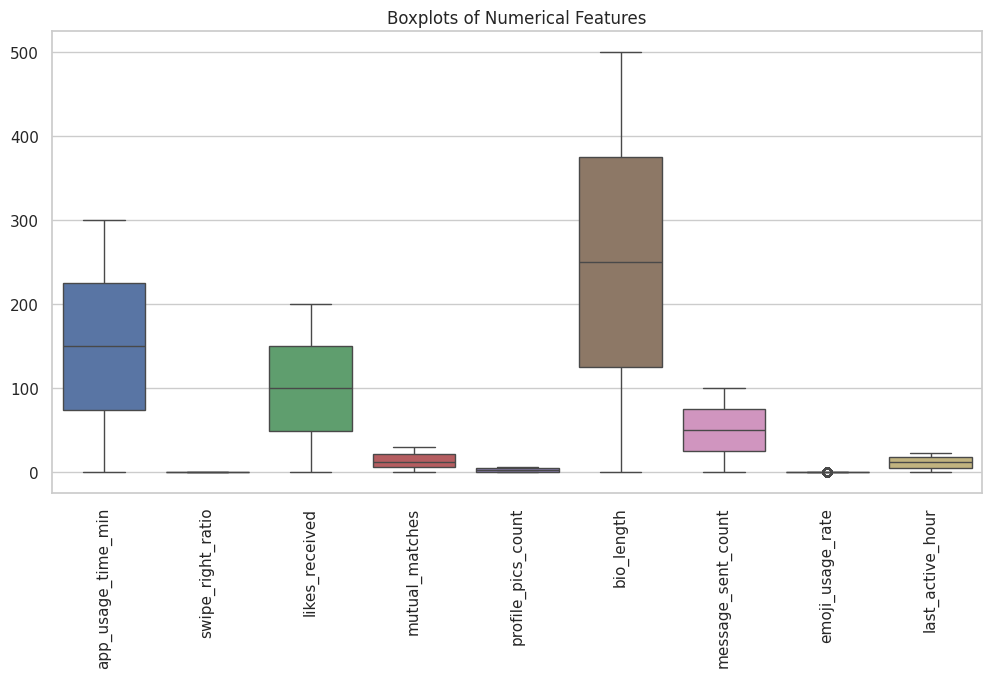

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.title("Boxplots of Numerical Features")
plt.show()


Outliers are present in several numerical features. These may negatively affect models that rely on distance calculations, such as Logistic Regression, but have less impact on tree-based models like Random Forest.

## Feature vs Target Relationship

We analyze how each numerical feature relates to the target variable.

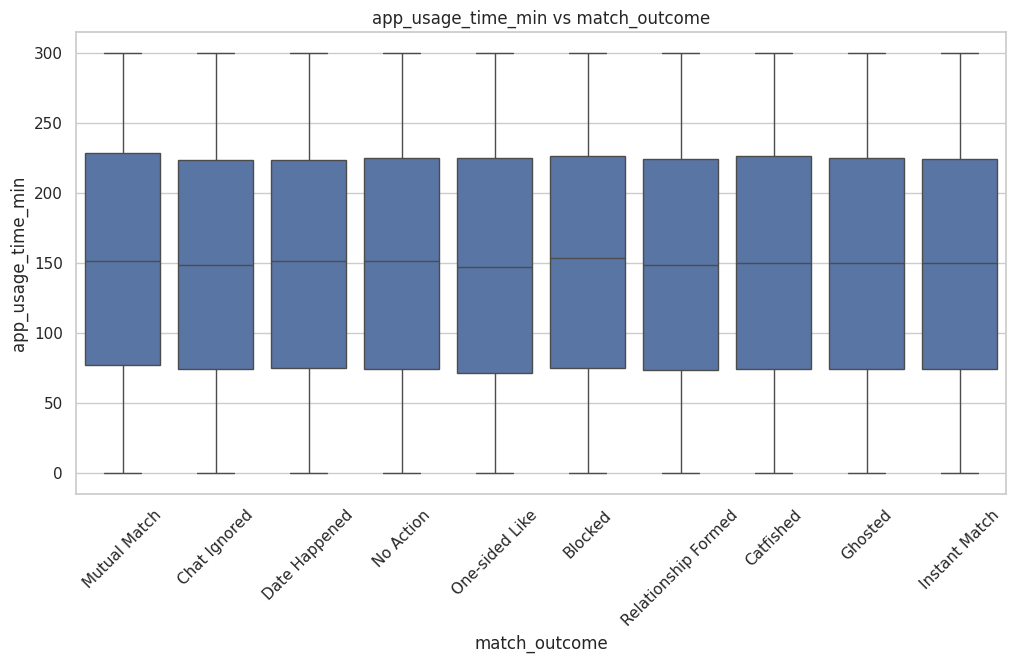

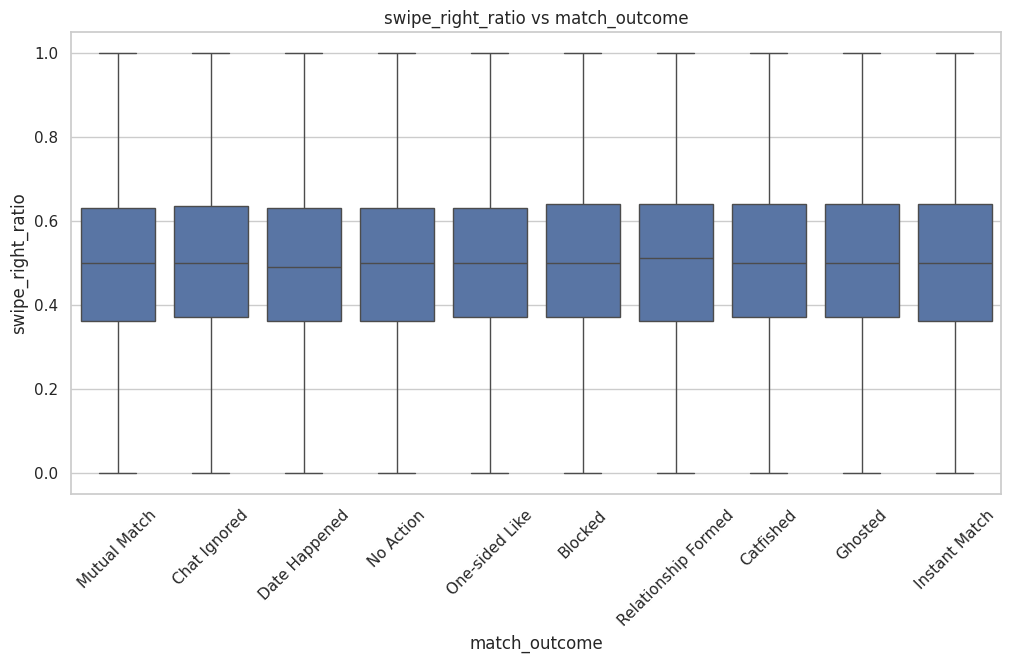

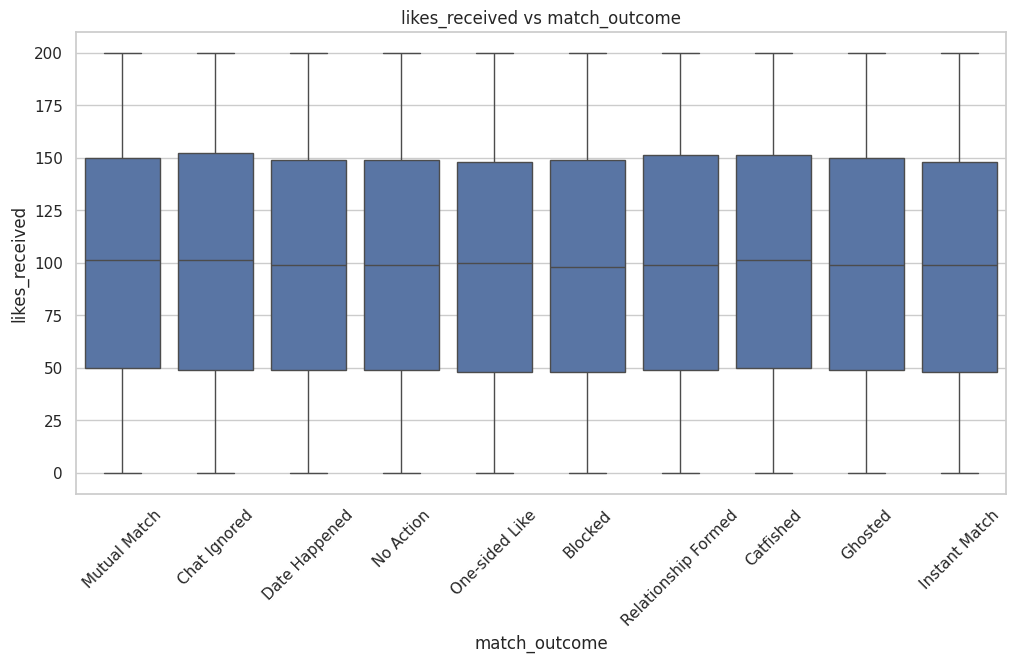

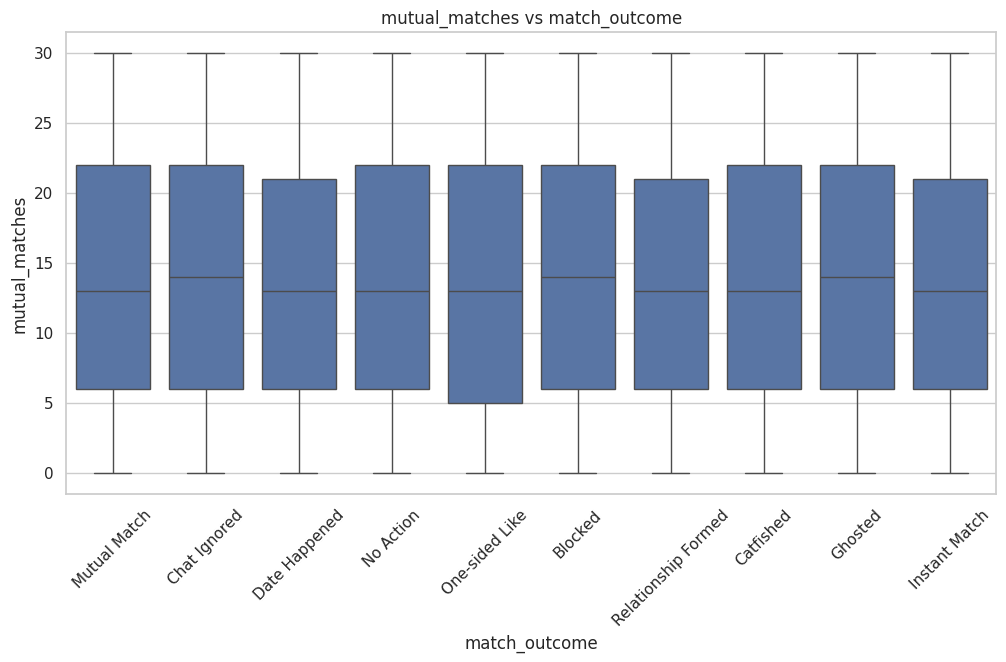

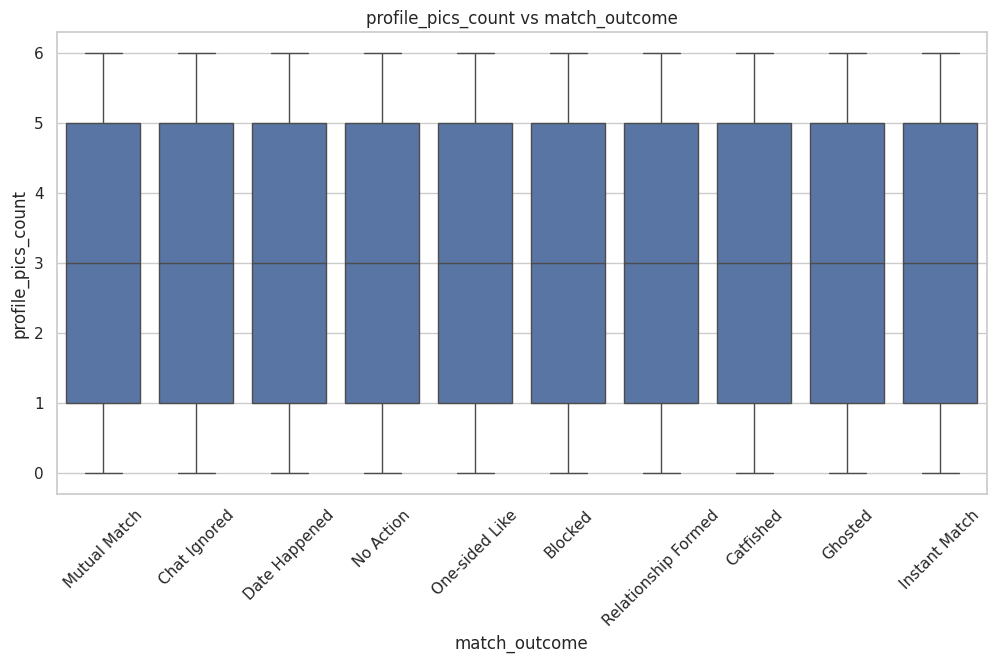

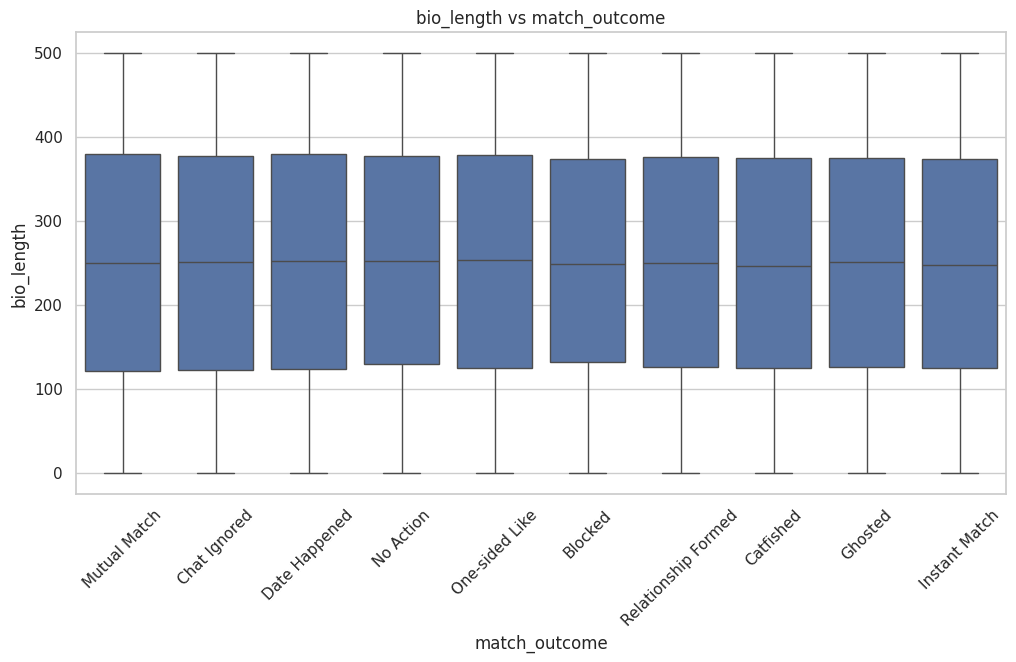

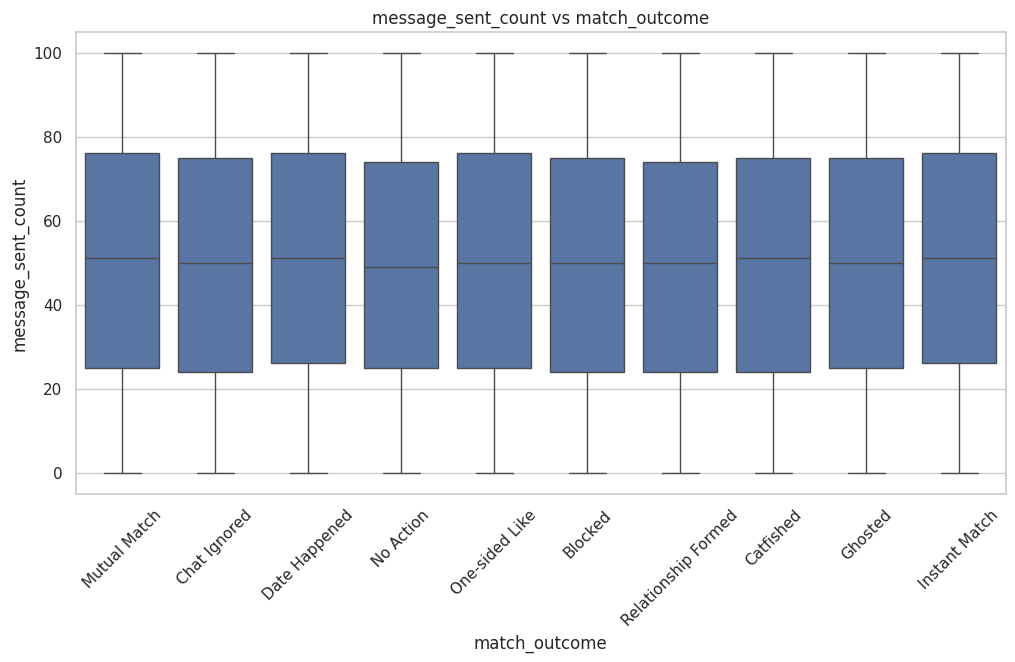

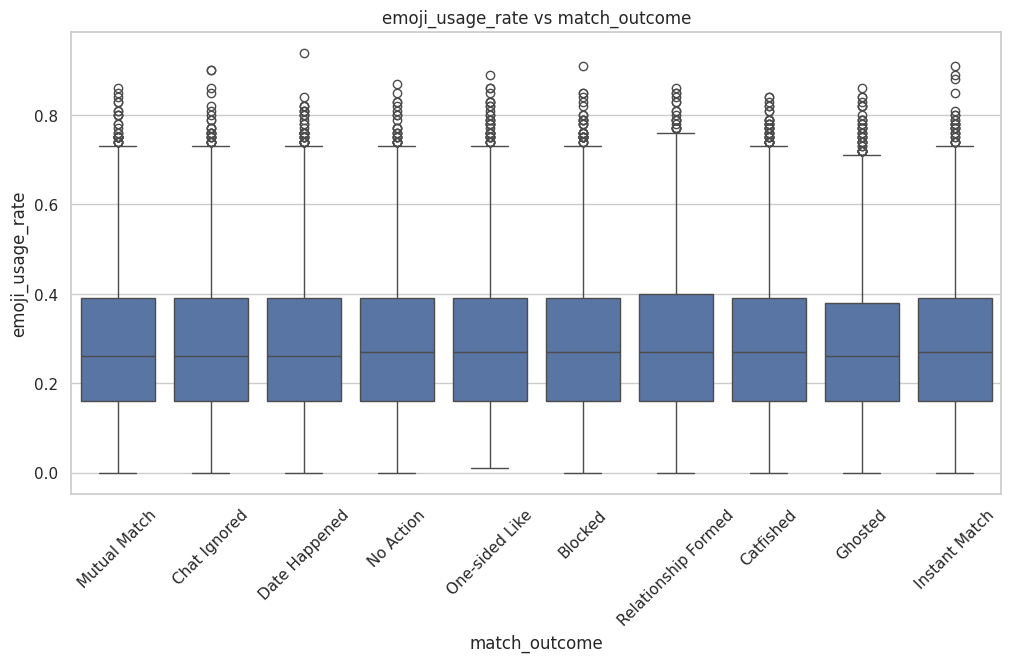

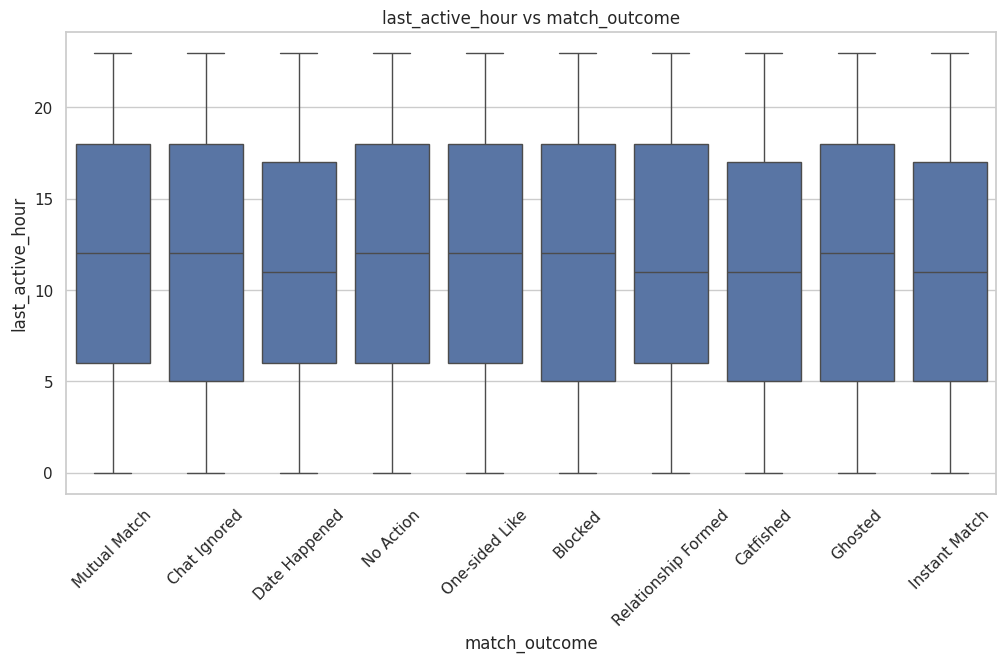

In [ ]:
for col in df.select_dtypes(include='number').columns:
    if col != TARGET:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x=TARGET, y=col, data=df)
        plt.title(f"{col} vs {TARGET}")
        plt.xticks(rotation=45)
        plt.show()


Certain features show clear separation between target classes, suggesting strong predictive power. These features are likely to play an important role in model performance.

# 3. Basic Machine Learning Models
In this section, we implement baseline classification models to predict match outcomes. These models serve as a benchmark before applying more advanced techniques.

## Train-test Split
>The dataset is split into training and testing sets to evaluate model performance on unseen data.



In [ ]:
X = df_scaled.drop("binary_match_outcome", axis=1)
y = df_scaled["binary_match_outcome"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (40000, 98)
Testing set: (10000, 98)


##Logistic Regression

>Logistic Regression is used as a baseline model to capture linear relationships between user behavior and match outcomes. It provides an interpretable benchmark for comparison with more complex models.



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=2000, solver='lbfgs')
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.603
              precision    recall  f1-score   support

           0       0.60      1.00      0.75      6030
           1       0.00      0.00      0.00      3970

    accuracy                           0.60     10000
   macro avg       0.30      0.50      0.38     10000
weighted avg       0.36      0.60      0.45     10000



##Confusion Matrix (Logistic)

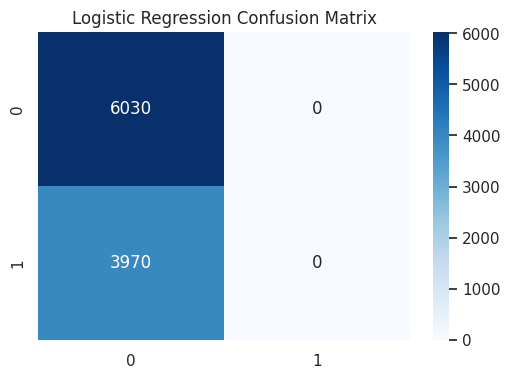

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

##Decision Tree Classifier (Non-Linear Model)

>The Decision Tree model captures non-linear patterns and decision rules in user behavior, allowing more flexible classification compared to linear models.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize model
tree_model = DecisionTreeClassifier(random_state=42)

# Train model
tree_model.fit(X_train, y_train)

# Predict
y_pred_tree = tree_model.predict(X_test)

In [ ]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.5228

Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.60      0.60      6030
           1       0.40      0.41      0.40      3970

    accuracy                           0.52     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.52      0.52      0.52     10000



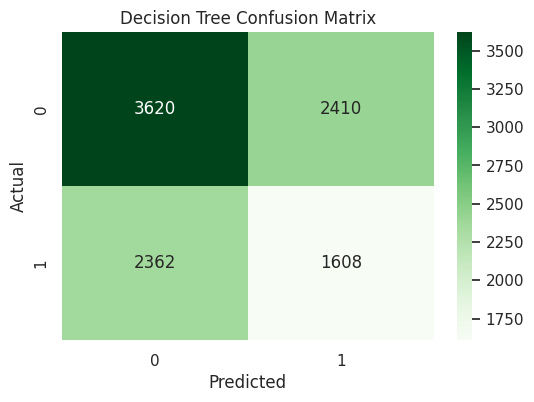

In [ ]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##Model Comparison (Basic Models)

>We compare both baseline models to evaluate whether non-linear decision rules improve prediction performance over linear modeling.

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression    0.6030
1        Decision Tree    0.5228


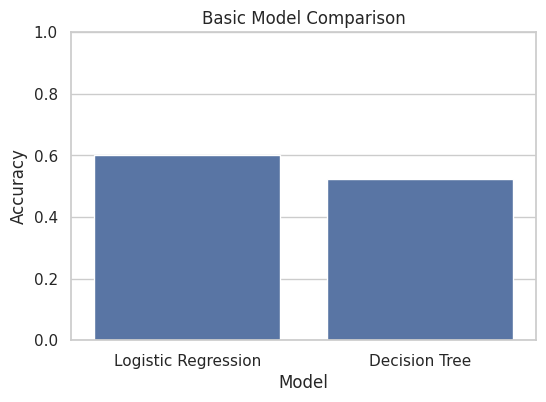

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Basic Model Comparison")
plt.ylim(0,1)
plt.show()

## Feature Importance (Decision Tree)

>We analyze feature importance from the Decision Tree model to identify which user behaviors most influence match outcomes.



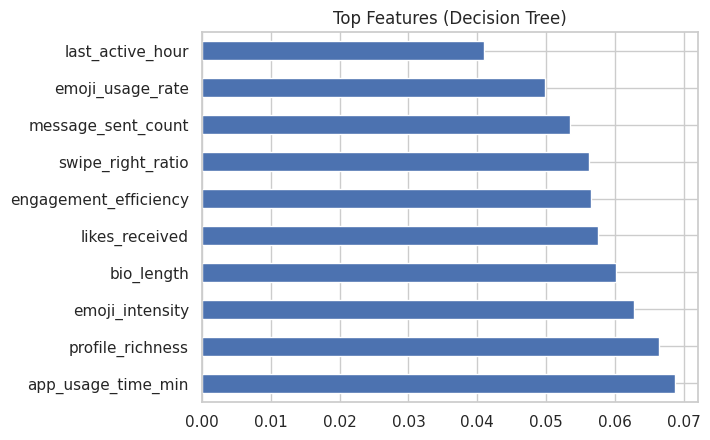

In [ ]:
import pandas as pd

importance = pd.Series(tree_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top Features (Decision Tree)")
plt.show()

# 4. Advanced Machine Learning Models
In this section, we implement advaced model to predict outcome, this advanced model will solving the overfitting and underfitting limitation from basic machine learning model

## Random Forest

Random Forest is used as an advanced ensemble model because it combines many decision trees to reduce overfitting and improve prediction stability. Since the target variable is match_outcome, the model learns behavioral, demographic, profile, and engagement patterns that influence dating success or failure.

In [ ]:
# ==============================
# Advanced Model 1: Random Forest
# ==============================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.6009

Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.99      0.75      6030
           1       0.34      0.01      0.01      3970

    accuracy                           0.60     10000
   macro avg       0.47      0.50      0.38     10000
weighted avg       0.50      0.60      0.46     10000



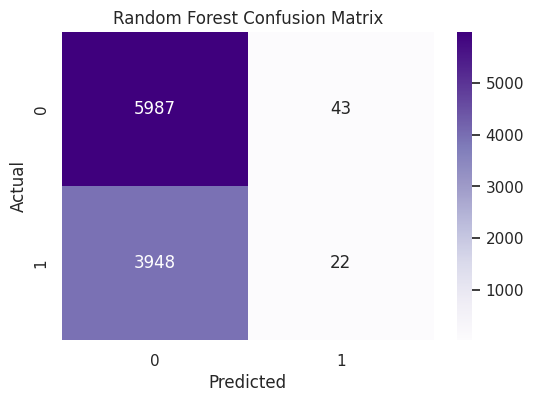

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Purples")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = SVC(
    kernel='rbf',
    probability=False,   # MUCH faster
    C=1,
    gamma='scale',
    random_state=42
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.6027

Classification Report:

              precision    recall  f1-score   support

           0       0.60      1.00      0.75      6030
           1       0.29      0.00      0.00      3970

    accuracy                           0.60     10000
   macro avg       0.44      0.50      0.38     10000
weighted avg       0.48      0.60      0.45     10000



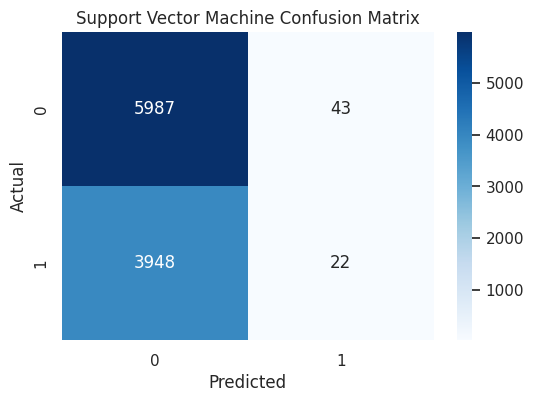

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Support Vector Machine Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## XGBoost

XGBoost is used as a stronger advanced model because it builds trees sequentially, where each new tree corrects the mistakes of the previous one. This makes it suitable for capturing complex non-linear patterns in dating app behavior.

In [ ]:
import numpy as np
from xgboost import XGBClassifier

# Calculate scale_pos_weight to handle class imbalance
# It's recommended to calculate this based on the training data
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
scale_pos_weight_value = neg_count / pos_count

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight_value # Add this parameter
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.5229

Classification Report:

              precision    recall  f1-score   support

           0       0.62      0.55      0.58      6030
           1       0.41      0.48      0.44      3970

    accuracy                           0.52     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.54      0.52      0.53     10000



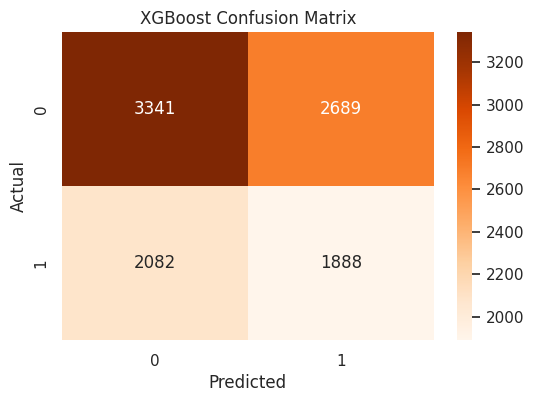

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Feature Importance

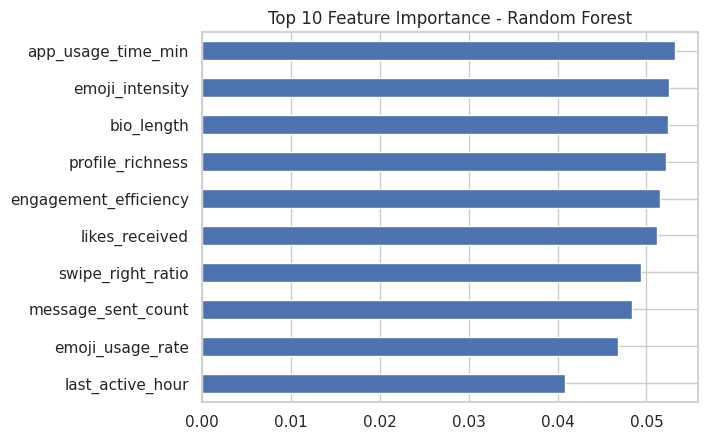

In [ ]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns)

rf_importance.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

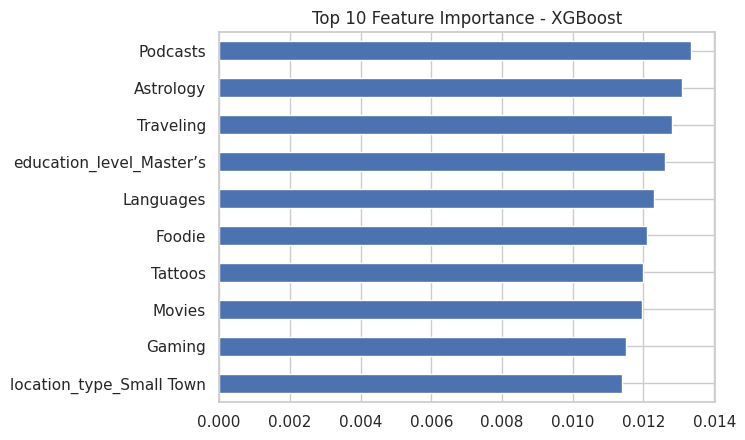

In [ ]:
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X.columns)

xgb_importance.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 Feature Importance - XGBoost")
plt.gca().invert_yaxis()
plt.show()

## Hyperparameter Tuning for XGBoost

We will use `GridSearchCV` to find the best hyperparameters for the XGBoost model. This involves testing different combinations of `n_estimators`, `learning_rate`, and `max_depth` to optimize performance.

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=scale_pos_weight_value # Maintain class imbalance handling
    ),
    param_grid=param_grid,
    cv=3, # Using 3-fold cross-validation
    scoring='f1', # Optimize for F1-score (good for imbalanced data)
    verbose=1, # Print progress
    n_jobs=-1 # Use all available cores
)

grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1-score found: ", grid_search.best_score_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


In [ ]:
best_xgb_model = grid_search.best_estimator_
print("Best XGBoost model extracted from GridSearchCV.")

### Evaluating the Tuned XGBoost Model

Now, let's train a new XGBoost model with the best parameters found and evaluate its performance on the test set.

In [ ]:
best_xgb_model = grid_search.best_estimator_

y_pred_best_xgb = best_xgb_model.predict(X_test)

print("Tuned XGBoost Accuracy:", accuracy_score(y_test, y_pred_best_xgb))
print("\nClassification Report (Tuned XGBoost):\n")
print(classification_report(y_test, y_pred_best_xgb))

cm_best_xgb = confusion_matrix(y_test, y_pred_best_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm_best_xgb, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Tuned XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##Model Comparison (Advanced Models)

We compare All models to determine whether which models perform better

In [ ]:
advanced_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "XGBoost (Untuned)",
        "XGBoost (Tuned)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_best_xgb)
    ],
    "Precision (Class 1)": [
        precision_score(y_test, y_pred_log, pos_label=1, zero_division=0),
        precision_score(y_test, y_pred_tree, pos_label=1, zero_division=0),
        precision_score(y_test, y_pred_rf, pos_label=1, zero_division=0),
        precision_score(y_test, y_pred_svm, pos_label=1, zero_division=0),
        precision_score(y_test, y_pred_xgb, pos_label=1, zero_division=0),
        precision_score(y_test, y_pred_best_xgb, pos_label=1, zero_division=0)
    ],
    "Recall (Class 1)": [
        recall_score(y_test, y_pred_log, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_tree, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_rf, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_svm, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_xgb, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_best_xgb, pos_label=1, zero_division=0)
    ],
    "F1-Score (Class 1)": [
        f1_score(y_test, y_pred_log, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_tree, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_rf, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_svm, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_xgb, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_best_xgb, pos_label=1, zero_division=0)
    ]
})

print(advanced_results)

plt.figure(figsize=(12,7))
sns.barplot(x="Model", y="Accuracy", data=advanced_results)
plt.title("Model Comparison - Accuracy")
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(12,7))
sns.barplot(x="Model", y="Recall (Class 1)", data=advanced_results)
plt.title("Model Comparison - Recall for Positive Class (Class 1)")
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.show()

# 5. Model Evaluation

##Consolidated Model Comparison
Summary of Accuracy, Precision, Recall, and F1-Score

In [ ]:
# Dictionary to store all model predictions
models_preds = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "XGBoost (Untuned)": y_pred_xgb,
    "XGBoost (Tuned)": y_pred_best_xgb
}

# Calculate metrics for all models
final_comparison = []
for name, preds in models_preds.items():
    final_comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, preds)
    })

comparison_df = pd.DataFrame(final_comparison).sort_values(by="F1-Score", ascending=False)
print("--- Final Model Comparison Table ---")
print(comparison_df)

--- Final Model Comparison Table ---
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
5      XGBoost (Tuned)    0.4952   0.403612  0.568514  0.472077  0.507723
4    XGBoost (Untuned)    0.5229   0.412497  0.475567  0.441792  0.514815
1        Decision Tree    0.5228   0.400199  0.405038  0.402604  0.502685
2        Random Forest    0.6009   0.338462  0.005542  0.010905  0.499205
3                  SVM    0.6027   0.285714  0.000504  0.001006  0.499837
0  Logistic Regression    0.6030   0.000000  0.000000  0.000000  0.500000


##Model Performance Comparison (Multiple Metrics)
* The grouped bar chart below helps us visually identify which model performs best overall and whether hyperparameter tuning improved the model performance.

* This comparison allows us to determine the most suitable model for predicting dating app match outcomes based on overall predictive capability and classification balance.

In [ ]:
plt.figure(figsize=(12, 6))
melted_df = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=melted_df, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison (Multiple Metrics)")
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##Top-3 Confusion Matrices
Visualizing errors for the best performing models

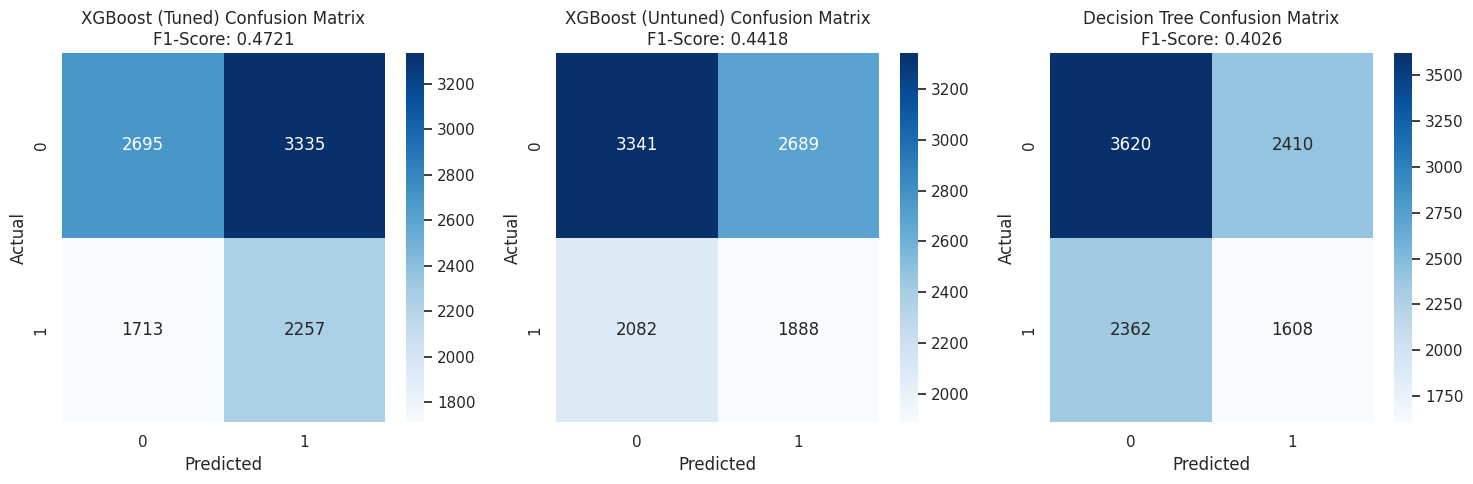

In [ ]:
# Get the top 3 models by F1-Score from comparison_df
top_3_models = comparison_df.head(3)

# Dictionary to map model names to their confusion matrices
confusion_matrices = {
    "XGBoost (Tuned)": cm_best_xgb,
    "XGBoost (Untuned)": cm_xgb,
    "Decision Tree": cm_tree,
    "SVM": cm_svm,
    "Random Forest": cm_rf,
    "Logistic Regression": cm_log
}

plt.figure(figsize=(15, 5))
for i, (index, row) in enumerate(top_3_models.iterrows()):
    model_name = row['Model']
    f1_score_val = row['F1-Score']
    cm = confusion_matrices[model_name]

    plt.subplot(1, 3, i + 1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix\nF1-Score: {f1_score_val:.4f}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

##ROC Curves for All 5 Models
Comparing model sensitivity and specificity on one chart

In [ ]:
# Dictionary of model objects to calculate probabilities
models_dict = {
    "Logistic Regression": log_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "XGBoost (Untuned)": xgb_model,
    "XGBoost (Tuned)": best_xgb_model
}

plt.figure(figsize=(10, 8))

for name, model in models_dict.items():
    # Get predicted probabilities for the positive class
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
    else:
        # Fallback for models that might not have predict_proba (though all these do)
        probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot the diagonal 50/50 line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - All Models')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Feature Importance Analysis (SHAP)

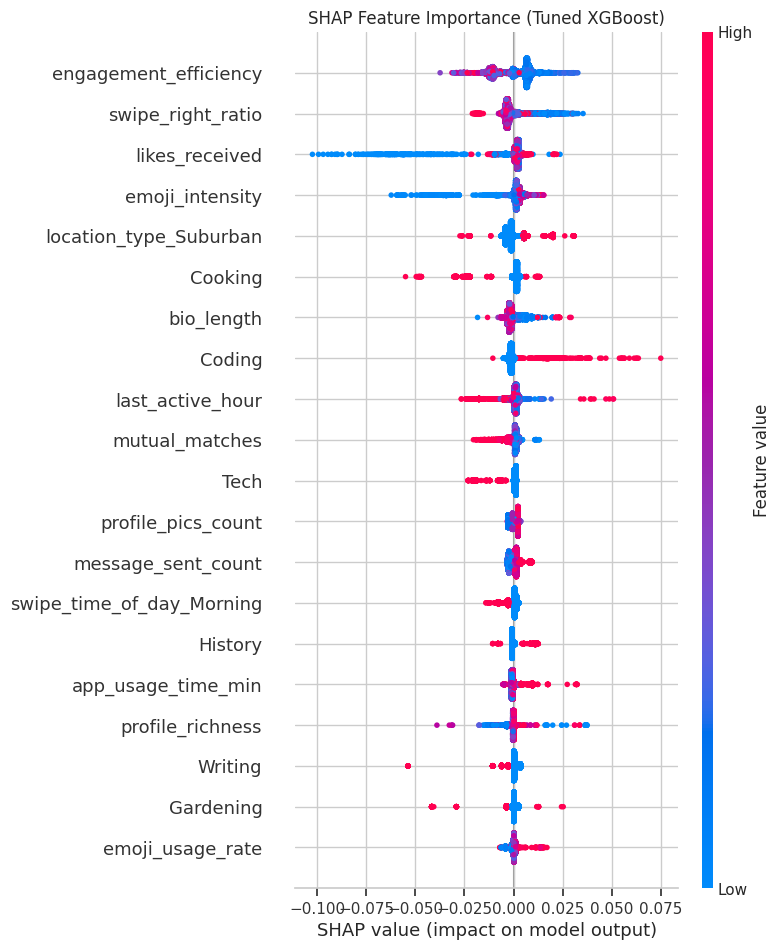

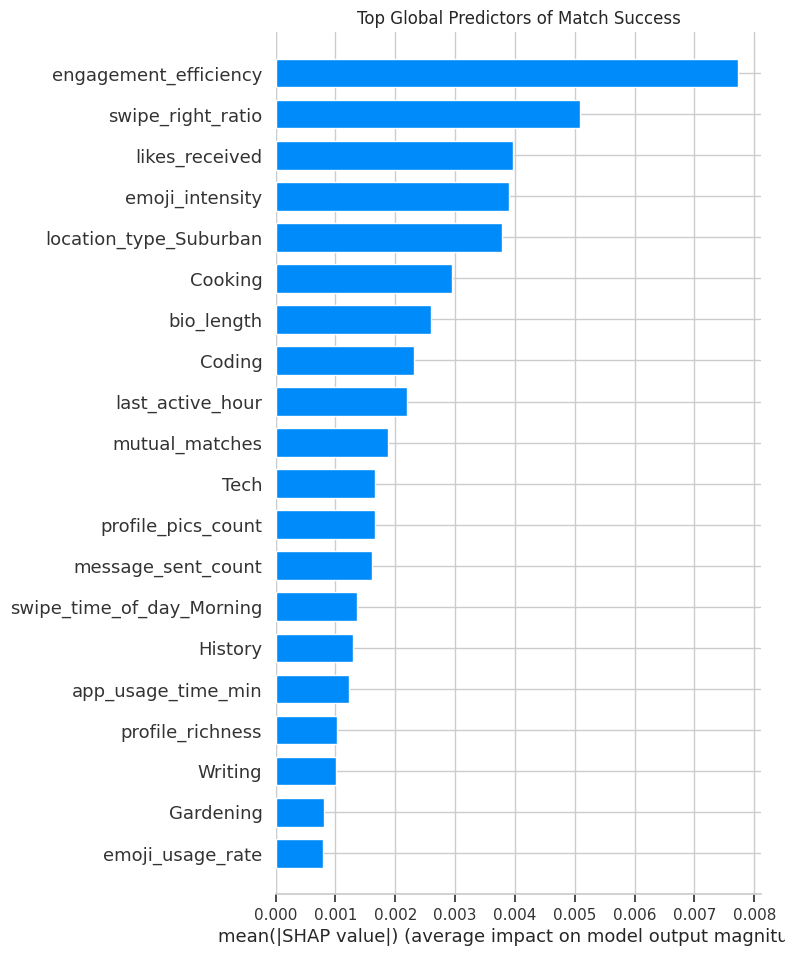

Top 10 Predictors of Match Success:
                        Feature  Importance
44                         Pets    0.043030
28                       Gaming    0.042508
60                      Writing    0.042080
7              emoji_usage_rate    0.039879
97    swipe_time_of_day_Morning    0.034468
33                        K-pop    0.034361
34                    Languages    0.033735
93  swipe_time_of_day_Afternoon    0.033143
55              Stand-up Comedy    0.031059
77       location_type_Suburban    0.030812


In [ ]:
# 1. Initialize the SHAP Explainer using the tuned XGBoost model
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_test)

# 2. Summary Plot: Global Feature Importance & Directionality
# This shows how much each feature contributes to the prediction
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)
plt.title("SHAP Feature Importance (Tuned XGBoost)")
plt.show()

# 3. Bar Plot: Mean Absolute SHAP values
# This provides a clean ranking of feature impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Top Global Predictors of Match Success")
plt.show()

# 4. Extracting the Numerical Importance Data for Report
# Mapping importance back to feature names for a clear table
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 10 Predictors of Match Success:")
print(feature_importances.head(10))

# 6. Auto-ML Comparison (FLAML)
Auto-sklearn could not be used in Colab/Windows environment, so FLAML was used as a lightweight AutoML alternativ

Modern Auto-ML Alternative: **FLAML** (Works on Python 3.10+, Windows,and Linux)

In [ ]:
# Install FLAML (Lightweight AutoML)
!pip install flaml

from flaml import AutoML

# Initialize AutoML
automl = AutoML()

# Specify settings
settings = {
    "time_budget": 120,    # total running time in seconds (2 minutes)
    "metric": 'f1',       # optimize for F1-score
    "task": 'classification',
    "log_file_name": 'dating_app_automl.log',
    "seed": 42,
}

print("\nStarting AutoML search (FLAML)...")
automl.fit(X_train=X_train, y_train=y_train, **settings)

# Predict and Evaluate
y_pred_automl = automl.predict(X_test)
automl_accuracy = accuracy_score(y_test, y_pred_automl)
automl_f1 = f1_score(y_test, y_pred_automl)

print(f"\nAutoML Best Model Found: {automl.best_estimator}")
print(f"AutoML Accuracy: {automl_accuracy:.4f}")
print(f"AutoML F1-Score: {automl_f1:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.7/349.7 kB 6.8 MB/s eta 0:00:00

Starting AutoML search (FLAML)...
[flaml.automl.logger: 05-28 07:06:38] {2375} INFO - task = classification
[flaml.automl.logger: 05-28 07:06:38] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 05-28 07:06:38] {2489} INFO - Minimizing error metric: 1-f1
[flaml.automl.logger: 05-28 07:06:38] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 05-28 07:06:38] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-28 07:06:39] {3046} INFO - Estimated sufficient time budget=3144s. Estimated necessary time budget=73s.
[flaml.automl.logger: 05-28 07:06:39] {3097} INFO -  at 1.7s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 05-28 07:06:39] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-28 07:06:39] {3097

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 05-28 07:06:40] {3097} INFO -  at 2.8s,	estimator sgd's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 05-28 07:06:40] {2911} INFO - iteration 4, current learner lgbm
[flaml.automl.logger: 05-28 07:06:40] {3097} INFO -  at 3.0s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 05-28 07:06:40] {2911} INFO - iteration 5, current learner xgboost
[flaml.automl.logger: 05-28 07:06:40] {3097} INFO -  at 3.4s,	estimator xgboost's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 05-28 07:06:40] {2911} INFO - iteration 6, current learner xgboost
[flaml.automl.logger: 05-28 07:06:41] {3097} INFO -  at 3.7s,	estimator xgboost's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 05-28 07:06:41] {2911} INFO - iteration 7, current learner lgbm
[flaml.automl.logger: 05-28 07:06:41] {3097} INFO -  at 4.0s,

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 05-28 07:08:39] {3097} INFO -  at 122.1s,	estimator lrl1's best error=1.0000e+00,	best estimator sgd's best error=4.3164e-01
[flaml.automl.logger: 05-28 07:08:40] {3359} INFO - retrain sgd for 0.6s
[flaml.automl.logger: 05-28 07:08:40] {3362} INFO - retrained model: SGDClassifier(alpha=np.float64(0.0005186766797846203),
              epsilon=np.float64(0.009292689536067506),
              eta0=np.float64(0.05679198174413306), l1_ratio=0.9999999999999999,
              learning_rate=np.str_('constant'), loss=np.str_('modified_huber'),
              n_jobs=-1, penalty=np.str_('elasticnet'), tol=0.0001)
[flaml.automl.logger: 05-28 07:08:40] {2636} INFO - fit succeeded
[flaml.automl.logger: 05-28 07:08:40] {2637} INFO - Time taken to find the best model: 116.32559633255005

AutoML Best Model Found: sgd
AutoML Accuracy: 0.5455
AutoML F1-Score: 0.3378



## Final Result: Manual VS. Auto-ML
Benchmarking manual models against Automated ML

In [ ]:
best_manual_f1 = comparison_df['F1-Score'].max()
print(f"\nYour Best Manual Model F1: {best_manual_f1:.4f}")
print(f"AutoML F1: {automl_f1:.4f}")

if automl_f1 > best_manual_f1:
    print(f"Conclusion: AutoML ({automl.best_estimator}) outperformed manual tuning.")
else:
    print("Conclusion: Your manual tuning was as good as or better than AutoML.")


Your Best Manual Model F1: 0.4721
AutoML F1: 0.3378
Conclusion: Your manual tuning was as good as or better than AutoML.


In [ ]:

import joblib
import json

# 1. Save the best model (tuned XGBoost from GridSearchCV)
joblib.dump(best_xgb_model, "best_xgb_model.pkl")
print("✅ best_xgb_model.pkl saved")

# 2. Save the StandardScaler
joblib.dump(scaler, "scaler.pkl")
print("✅ scaler.pkl saved")

# 3. Save the list of feature column names (after get_dummies + feature engineering)
#    X is the feature matrix defined before train_test_split in your notebook
model_columns = list(X.columns)
with open("model_columns.json", "w") as f:
    json.dump(model_columns, f)
print(f"✅ model_columns.json saved  ({len(model_columns)} columns)")

# 4. Download all three files to your local machine
from google.colab import files
files.download("best_xgb_model.pkl")
files.download("scaler.pkl")
files.download("model_columns.json")

✅ best_xgb_model.pkl saved
✅ scaler.pkl saved
✅ model_columns.json saved  (98 columns)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>